# Exploring the MOC

*Developed starting from activities by Sarah Purkey at Scripps Institution of Oceanography, University of
California San Diego; used in courses such as SIO 210.*

This notebook uses the Argo array to sample the ocean meridionally and identify the water masses that make up the Meridional Overturning Circulation (MOC).

This notebook uses the Argovis web app and database. Argovis provides an API that indexes and distributes numerous oceanographic datasets with detailed query parameters, enabling you to search and download only and exactly the data of interest.

## Learning Goals

By the end of this activity, you will be able to:

1. **Construct a meridional water-mass section** — assemble profiles spanning a full ocean basin, display them south to north, and identify major water masses.
2. **Read T–S diagrams** — associate clusters in T–S space with specific water masses and depth ranges.
3. **Describe the large-scale T/S structure** — quantify how surface and deep (1750 dbar) temperature and salinity change with latitude.

## Setup: register an API key

In order to allocate Argovis's limited computing resources fairly, users are encouraged to register and request a free API key. This works like a password that identifies your requests to Argovis.

1. Visit [https://argovis-keygen.colorado.edu/](https://argovis-keygen.colorado.edu/)
2. Fill out the form under **New Account Registration**
3. An API key will be emailed to you shortly

Treat your API key like a password — don't share it or leave it anywhere public. If you ever forget it or accidentally reveal it, visit the same website to change or deactivate your token.

Set `APIKEY` in the cell below before running anything else. The notebook may still work with `'guest'` but may return errors under heavy load.

## Setup: import libraries and functions

The cells below import all required scientific libraries and the notebook helper functions from `notebook_helpers/`. Run them in order before anything else.

In [1]:
# ── Imports — run this cell first, do not modify ──────────────────────────────
from argovisHelpers import helpers as avh
from argovisHelpers import analysis as ava
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.dates as mdates
import gsw
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

APIKEY  = 'guest'  # ← paste your key here
APIROOT = 'https://argovis-api.colorado.edu/'

## Setup: import helper functions

The functions below are used throughout the notebook. You do not need to edit them.
- `traverse_query` — loop over all region × time × dataset combinations and call the Argovis API
- `traverse_interpolate` — interpolate all queried profiles onto a common pressure grid
- `plot_maps` — scatter profile locations on a map
- `compare_profiles` — plot individual or mean vertical profiles; to plot means, pre-average with `average_profiles_dict` and pass `mean_style=True`
- `plot_profiles_TSdiagram` — T/S diagram with optional coloring by a third variable
- `plot_profiles_with_mld` — plot profiles with student and algorithmic MLD markers
- `compute_derived_properties` — compute SA, CT, potential density, MLD (3 methods), and N² for each profile
- `_arr` — safely convert Profile.getvar() output to a plain float ndarray

In [2]:
# ── Helper functions — run, do not modify ────────────────────────────────────
from notebook_helpers.functions import traverse_query, traverse_interpolate, plot_maps, compare_profiles, plot_profiles_TSdiagram
from notebook_helpers.functions_MLD import plot_profiles_with_mld, compute_derived_properties
from notebook_helpers.functions_candidates_for_functions import _arr

---
## Exploring the MOC with Argovis

The **Meridional Overturning Circulation (MOC)** redistributes heat, salt, and carbon across ocean basins. By sampling profiles from south to north within a single basin, we can visualize the water masses that make up this circulation and how temperature and salinity change with latitude and depth.

### Step 0 — Choose your ocean and profiles

Choose either the **Atlantic** or the **Pacific** ocean (not the Arctic, Indian, or Southern Ocean). On [argovis.colorado.edu/argo](https://argovis.colorado.edu/argo), identify **six Argo profiles** spanning the full meridional extent of the basin:

| # | Target latitude | Example range |
|---|-----------------|---------------|
| 1 | Far south        | south of 50°S |
| 2 | Southern subtropics | 15°S – 40°S |
| 3 | Near equator     | 10°S – 10°N |
| 4 | Northern subtropics | 15°N – 40°N |
| 5 | Northern mid-latitudes | 40°N – 55°N |
| 6 | Far north        | north of 55°N |

**Keep your profiles at approximately the same longitude** — you want to sample along a meridian, not compare across basins. Note each profile's full ID (e.g. `4902898_151`), latitude, and longitude.

## Setup: configuration

✏️ **Student Work — Meridional Profile Selection**

Replace the six example IDs below with your chosen profile IDs, listed **south to north**. Update `MOC_OCEAN` with your chosen basin name.

In [3]:
# MODIFY HERE
MOC_OCEAN = 'Pacific'   # ← 'Atlantic' or 'Pacific'

# Replace the profile IDs below with your chosen profiles, listed south to north.
# The key must always be "id"; the value is the profile ID (platform_cycle).
# Keep profiles at roughly the same longitude — the example IDs below are all
# near 173–179°E (western Pacific / date-line region).
# Do NOT mix profiles from different basins — check the map in Step 3 to verify.
moc_profiles = [
    {"id": "6900929_153"},   # far south             (south of 50°S) | lat≈−57°N, lon≈173°E
    {"id": "5901910_259"},   # southern subtropics   (15°S – 40°S)   | lat≈−21°N, lon≈178°E
    {"id": "5905717_293"},   # near equator          (10°S – 10°N)   | lat≈−3°N,  lon≈179°E
    {"id": "2903428_176"},   # northern subtropics   (15°N – 40°N)   | lat≈+23°N, lon≈178°E
    {"id": "5906354_186"},   # northern mid-latitudes (40°N – 55°N)  | lat≈+48°N, lon≈177°E
    {"id": "4903210_262"},   # far north             (north of 55°N) | lat≈+59°N, lon≈178°E
]

# ── Fixed settings — do not modify ───────────────────────────────────────────
MOC_COLORS   = ['#a50026', '#f46d43', '#fdae61', '#66bd63', '#3288bd', '#5e4fa2']
MOC_TIME     = [{"startDate": "2000-01-01T00:00:00Z", "endDate": "2030-01-01T00:00:00Z"}]
INTERPOLATION_LEVELS = list(range(0, 2001, 5))   # 0–2000 dbar every 5 dbar
MOC_DEPTH    = 2000   # dbar — full-depth profiles plot
MOC_SHALLOW  = 500    # dbar — upper-ocean zoom

temperature_key = {'argo': 'temperature'}
salinity_key    = {'argo': 'salinity'}

### Step 1 — Query and interpolate meridional profiles

In [4]:
# ── Step 1: Query profiles — run, do not modify ───────────────────────────────
moc_results  = traverse_query(moc_profiles, MOC_TIME,
                              {'argo': 'temperature,1,salinity,1'},
                              avh.queryProfile, apikey=APIKEY, apiroot=APIROOT)
moc_pprofiles = traverse_interpolate(moc_results, INTERPOLATION_LEVELS)

n_moc = sum(len(tl) for rl in moc_pprofiles.get('argo', []) for tl in rl)
print(f"Loaded {n_moc} meridional profile(s)")

Loaded 5 meridional profile(s)


### Step 2 — Compute derived properties

In [5]:
# ── Compute derived properties — run, do not modify ──────────────────────────
for ds, regions_list in moc_pprofiles.items():
    for region_list in regions_list:
        for time_list in region_list:
            for p in time_list:
                if p.hasvar('temperature') and p.hasvar('salinity'):
                    compute_derived_properties(p, temperature_key, salinity_key, ds)

print("✓ Derived properties computed")

✓ Derived properties computed


### Step 3 — Map of profile locations

Verify that your six profiles are roughly aligned in longitude and span the intended latitude range.

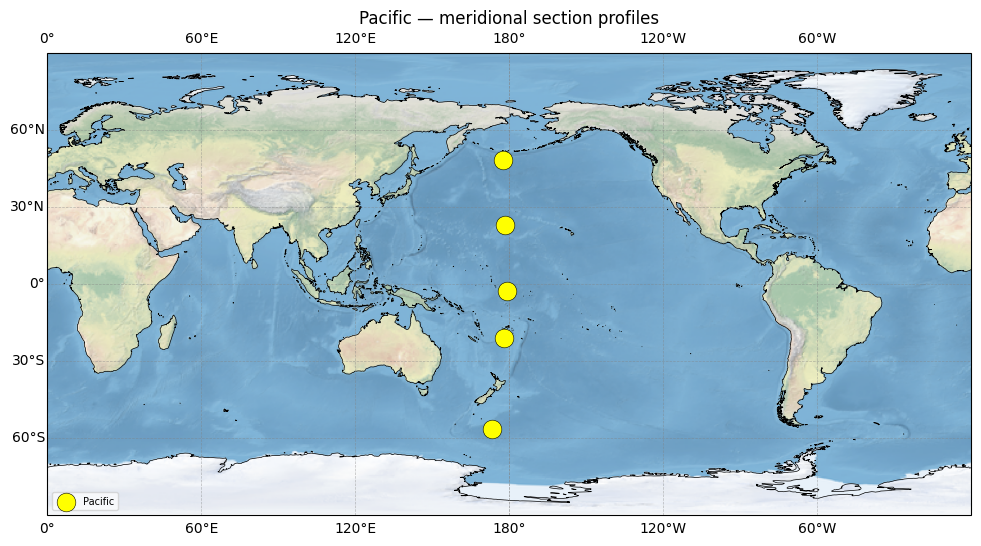

<GeoAxes: title={'center': 'Pacific — meridional section profiles'}>

In [6]:
# ── Map — run, do not modify ──────────────────────────────────────────────────
moc_lats, moc_lons, moc_labels = [], [], []
moc_flat = []
for ds, regions_list in moc_pprofiles.items():
    for region_list in regions_list:
        for time_list in region_list:
            if time_list:
                moc_flat.append(time_list[0])

moc_flat.sort(key=lambda p: p.latitude)
for p in moc_flat:
    moc_lats.append(p.latitude)
    moc_lons.append(p.longitude)

plot_maps(
    [moc_lats], [moc_lons],
    title=f'{MOC_OCEAN} — meridional section profiles',
    labels=[MOC_OCEAN],
    colors=['yellow'],
    markers=['o'],
    markersize=8,
    global_view=True,
    central_longitude=180 if MOC_OCEAN == 'Pacific' else 0,
    fig_settings={'figsize': (14, 6)},
)

### Step 4 — Temperature and salinity profiles (south to north)

The panels below display temperature (top row) and salinity (bottom row) for each of your six profiles. **Each panel title shows the profile latitude** — the profiles are arranged from south (left) to north (right). Examine how the temperature and salinity structure — surface values, thermocline / halocline depth and strength, and deep properties — evolve from one end of the basin to the other.

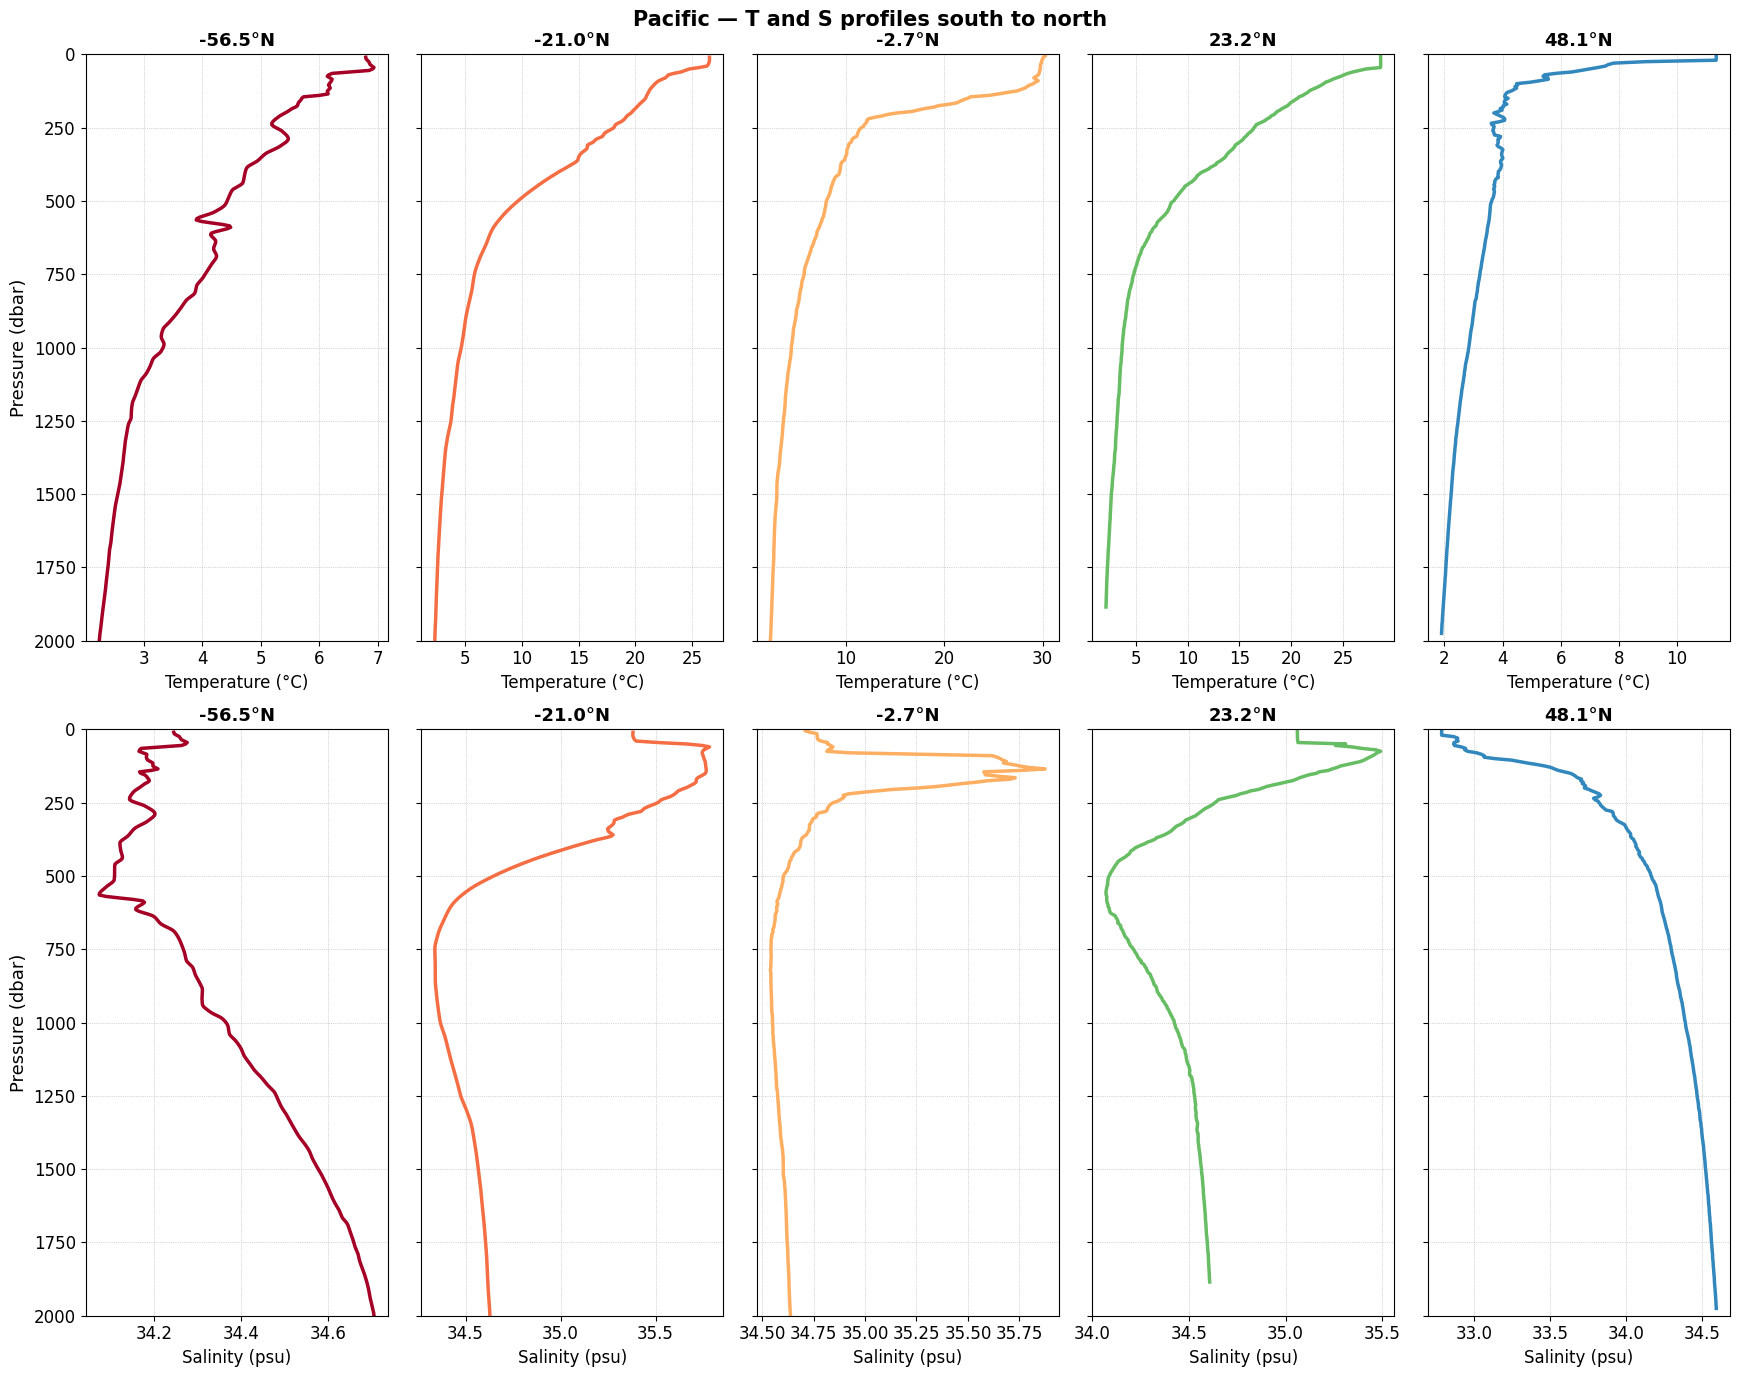

In [7]:
# ── T and S profiles south to north — run, do not modify ─────────────────────
n = len(moc_flat)
fig, axes = plt.subplots(2, n, figsize=(3.5 * n, 14), sharey='row')

for col, p in enumerate(moc_flat):
    color = MOC_COLORS[col % len(MOC_COLORS)]
    lat_label = f'{p.latitude:.1f}°N'

    for row, var in enumerate(['temperature', 'salinity']):
        ax = axes[row][col] if n > 1 else axes[row]
        compare_profiles(
            {'argo': [p]}, varname=var,
            dataset_colors={'argo': color}, time_linestyles=['-'],
            depth_ylim=MOC_DEPTH, mean_style=True,
            ax=ax,
        )
        ax.set_title(lat_label, fontsize=13, fontweight='bold')
        if col > 0:
            ax.set_ylabel('')
        ax.tick_params(labelsize=12)

# Thicken all profile lines and fix x-axis labels overwritten by compare_profiles
for col in range(n):
    ax_T = axes[0][col] if n > 1 else axes[0]
    ax_S = axes[1][col] if n > 1 else axes[1]
    for ax in [ax_T, ax_S]:
        for line in ax.get_lines():
            line.set_linewidth(2.5)
    ax_T.set_xlabel('Temperature (°C)', fontsize=12)
    ax_S.set_xlabel('Salinity (psu)',   fontsize=12)

axes[0][0].set_ylabel('Pressure (dbar)', fontsize=13)
axes[1][0].set_ylabel('Pressure (dbar)', fontsize=13)
plt.suptitle(f'{MOC_OCEAN} — T and S profiles south to north', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 5 — T–S diagrams colored by latitude

Each profile occupies a characteristic region in T–S space. Coloring by latitude reveals how water-mass T–S properties shift from one end of the basin to the other.

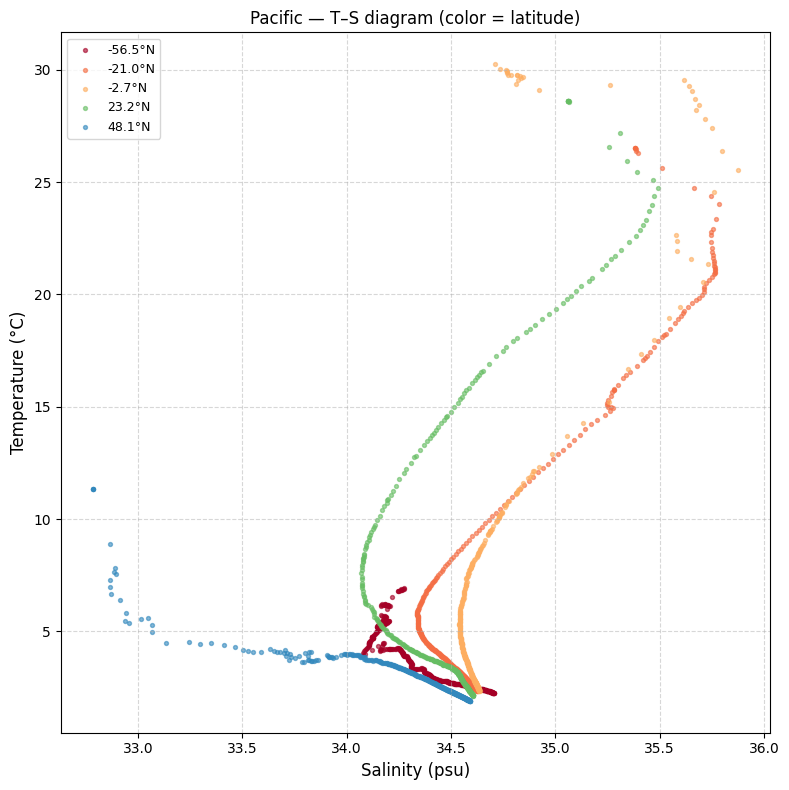

In [8]:
# ── T–S diagram colored by latitude — run, do not modify ─────────────────────
fig, ax = plt.subplots(figsize=(8, 8))

for col, p in enumerate(moc_flat):
    color = MOC_COLORS[col % len(MOC_COLORS)]
    t  = _arr(p.getvar('temperature'))
    s  = _arr(p.getvar('salinity'))
    pr = _arr(p.getvar('pressure'))
    valid = ~np.isnan(t) & ~np.isnan(s)
    ax.scatter(s[valid], t[valid], color=color, s=8, alpha=0.6,
               label=f'{p.latitude:.1f}°N')

ax.set_xlabel('Salinity (psu)', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title(f'{MOC_OCEAN} — T–S diagram (color = latitude)', fontsize=12)
ax.legend(fontsize=9, loc='best')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Step 6 — Temperature and salinity vs. latitude at the surface and at 1750 dbar

The plots below summarize how surface (~0 dbar) and deep (~1750 dbar) temperature and salinity change with latitude across the basin. The 1750 dbar level is chosen because it is within reach of most deep Argo profiles while still sampling the abyssal water masses.

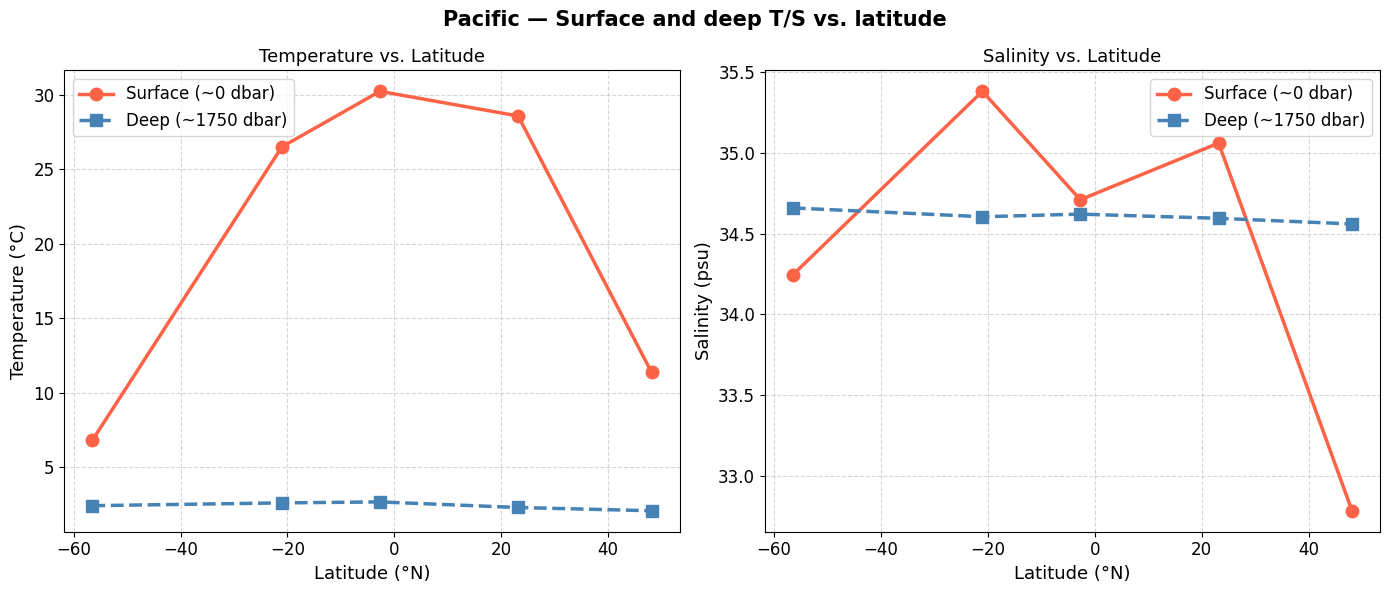

In [9]:
# ── T and S vs latitude at surface and 1750 dbar — run, do not modify ─────────
TARGET_DEPTHS = [0, 1750]   # dbar

lats_plot, T_surf, S_surf, T_deep, S_deep = [], [], [], [], []

for p in moc_flat:
    pres = _arr(p.getvar('pressure'))
    temp = _arr(p.getvar('temperature'))
    sal  = _arr(p.getvar('salinity'))
    valid = ~np.isnan(temp) & ~np.isnan(sal) & ~np.isnan(pres)
    if not valid.any():
        continue
    pv, tv, sv = pres[valid], temp[valid], sal[valid]
    order = np.argsort(pv)
    lats_plot.append(p.latitude)
    T_surf.append(float(np.interp(TARGET_DEPTHS[0], pv[order], tv[order])))
    S_surf.append(float(np.interp(TARGET_DEPTHS[0], pv[order], sv[order])))
    if pv.max() >= TARGET_DEPTHS[1]:
        T_deep.append(float(np.interp(TARGET_DEPTHS[1], pv[order], tv[order])))
        S_deep.append(float(np.interp(TARGET_DEPTHS[1], pv[order], sv[order])))
    else:
        T_deep.append(np.nan)
        S_deep.append(np.nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(lats_plot, T_surf, 'o-', color='tomato',    markersize=9, linewidth=2.5,
         label='Surface (~0 dbar)')
ax1.plot(lats_plot, T_deep, 's--', color='steelblue', markersize=9, linewidth=2.5,
         label='Deep (~1750 dbar)')
ax1.set_xlabel('Latitude (°N)', fontsize=13)
ax1.set_ylabel('Temperature (°C)', fontsize=13)
ax1.set_title('Temperature vs. Latitude', fontsize=13)
ax1.legend(fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.tick_params(labelsize=12)

ax2.plot(lats_plot, S_surf, 'o-', color='tomato',    markersize=9, linewidth=2.5,
         label='Surface (~0 dbar)')
ax2.plot(lats_plot, S_deep, 's--', color='steelblue', markersize=9, linewidth=2.5,
         label='Deep (~1750 dbar)')
ax2.set_xlabel('Latitude (°N)', fontsize=13)
ax2.set_ylabel('Salinity (psu)', fontsize=13)
ax2.set_title('Salinity vs. Latitude', fontsize=13)
ax2.legend(fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.tick_params(labelsize=12)

plt.suptitle(f'{MOC_OCEAN} — Surface and deep T/S vs. latitude', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## ✏️ Student Work — Question 5: Meridional Temperature and Salinity Structure

Using the profile panels, T–S diagram, and latitude plots above, answer the following questions.

Looking at the T and S profiles (Step 4): describe the temperature and salinity structure for each of your six profiles. What is the surface temperature and salinity range across the basin? What is the range at 2000 dbar?

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 6: T–S Diagram Overlap Across Latitudes

In the T–S diagram (Step 5), do the profiles overlap in T–S space at certain depths? What does that tell you about whether those water masses are found at multiple latitudes?

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 7: Identifying Water Masses in Your Transect

Can you identify any water masses from lecture in your profiles? For each one you identify, note the approximate depth, temperature, and salinity, and explain what distinguishes it in T–S space.

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 8: Surface vs. Deep Temperature and Salinity Across Latitude

Looking at the latitude vs. T/S plots (Step 6): describe how surface temperature and salinity change from the southern end to the northern end of your transect. How does the deep (1750 dbar) temperature compare to the surface temperature — is the deep ocean relatively uniform with latitude or does it vary strongly? What do you conclude about the source and spreading of deep water?

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 9: Deep Water Formation (Extra Credit)

Based on the property distributions you observe, where might you expect deep water to be forming? What properties (temperature, salinity, density) would you look for as evidence of deep-water formation?

*Double-click to edit this cell and write your answer.*